In [ ]:
import zipfile
import os
import cv2

zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)
images = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def load_and_preprocess_images(base_path, img_size=(128, 128)):
    images = []
    labels = []

    yes_path = os.path.join(base_path, 'yes')
    no_path = os.path.join(base_path, 'no')

    if os.path.exists(yes_path):
        for filename in os.listdir(yes_path):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                img_path = os.path.join(yes_path, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, img_size)
                    images.append(img)
                    labels.append(1)

    if os.path.exists(no_path):
        for filename in os.listdir(no_path):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                img_path = os.path.join(no_path, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, img_size)
                    images.append(img)
                    labels.append(0)

    return np.array(images), np.array(labels)

IMG_SIZE = (128, 128)

X, y = load_and_preprocess_images(extract_path, IMG_SIZE)

print(f"Total images loaded: {len(X)}")
print(f"Shape of image data (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

print("Data shuffled.")

X_normalized = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"\nShape of flattened X_train: {X_train_flat.shape}")
print(f"Shape of flattened X_test: {X_test_flat.shape}")

Total images loaded: 253
Shape of image data (X): (253, 128, 128, 3)
Shape of labels (y): (253,)
Data shuffled.

Shape of X_train: (202, 128, 128, 3)
Shape of X_test: (51, 128, 128, 3)
Shape of y_train: (202,)
Shape of y_test: (51,)

Shape of flattened X_train: (202, 49152)
Shape of flattened X_test: (51, 49152)


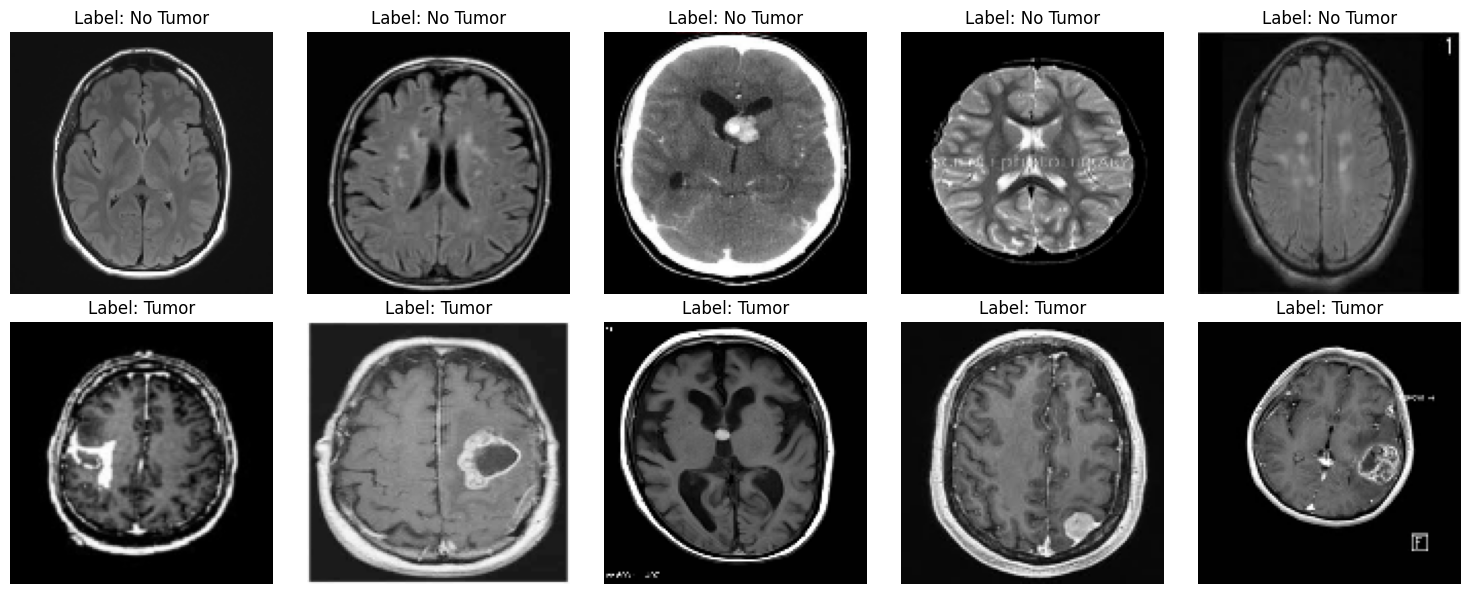

In [ ]:
def plot_samples(X, y, num_samples=5):
    plt.figure(figsize=(15, 6))
    unique_labels = np.unique(y)

    for label_val in unique_labels:
        label_indices = np.where(y == label_val)[0]
        sample_indices = np.random.choice(label_indices, min(num_samples, len(label_indices)), replace=False)

        for i, idx in enumerate(sample_indices):
            plt.subplot(len(unique_labels), num_samples, label_val * num_samples + i + 1)
            display_img = (X[idx] * 255).astype(np.uint8)
            plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
            plt.title(f'Label: {"Tumor" if label_val == 1 else "No Tumor"}')
            plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_samples(X_normalized, y, num_samples=5)

In [ ]:
logistic_model = LogisticRegression(max_iter=2000, random_state=42)
logistic_model.fit(X_train_flat, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
y_pred = logistic_model.predict(X_test_flat)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8039

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.86      0.81      0.83        31

    accuracy                           0.80        51
   macro avg       0.79      0.80      0.80        51
weighted avg       0.81      0.80      0.81        51


Confusion Matrix:
[[16  4]
 [ 6 25]]


In [ ]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, verbose=3, n_jobs=-1)

print("Starting GridSearchCV for SVM... This might take some time.")
grid_search.fit(X_train_flat, y_train)

print(f"\nBest parameters found: {grid_search.best_params_}")

best_svm_model = grid_search.best_estimator_
print("Best SVM model obtained through GridSearchCV.")

Starting GridSearchCV for SVM... This might take some time.
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM model obtained through GridSearchCV.


In [ ]:
y_pred_best_svm = best_svm_model.predict(X_test_flat)

print(f"Tuned SVM Accuracy: {accuracy_score(y_test, y_pred_best_svm):.4f}")
print("\nTuned SVM Classification Report:")
print(classification_report(y_test, y_pred_best_svm))
print("\nTuned SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_svm))

Tuned SVM Accuracy: 0.8431

Tuned SVM Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.85      0.90      0.88        31

    accuracy                           0.84        51
   macro avg       0.84      0.83      0.83        51
weighted avg       0.84      0.84      0.84        51


Tuned SVM Confusion Matrix:
[[15  5]
 [ 3 28]]


In [ ]:
from google.colab import files
import io

uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        uploaded_image_path = f"/content/{filename}"
        print(f"Successfully uploaded: {uploaded_image_path}")
else:
    print("No file was uploaded.")

Saving tumour.jpg to tumour (2).jpg
Successfully uploaded: /content/tumour (2).jpg


Using uploaded image for prediction: /content/tumour (2).jpg
Prediction for image '/content/tumour (2).jpg': Tumor Detected
Decision Function Score (Positive for Tumor, Negative for No Tumor): 0.6534


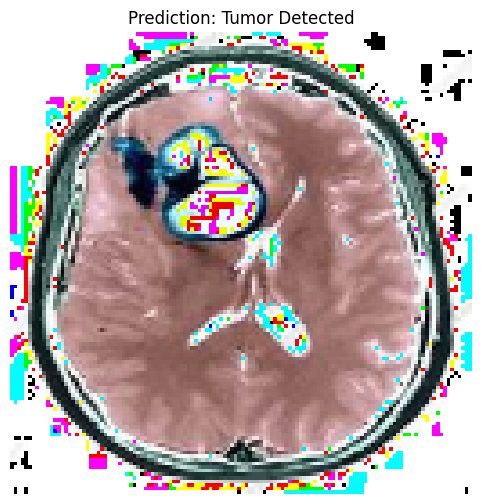

In [ ]:
def preprocess_single_image(image_path, img_size=(128, 128)):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    img_resized = cv2.resize(img, img_size)
    img_normalized = img_resized / 255.0
    img_flat = img_normalized.reshape(1, -1)

    return img_flat, img_resized

new_image_path = uploaded_image_path
print(f"Using uploaded image for prediction: {new_image_path}")

if new_image_path and os.path.exists(new_image_path):
    processed_image_flat, original_resized_img = preprocess_single_image(new_image_path, IMG_SIZE)

    if processed_image_flat is not None:
        prediction = best_svm_model.predict(processed_image_flat)
        prediction_proba = best_svm_model.decision_function(processed_image_flat)
        result = "Tumor Detected" if prediction[0] == 1 else "No Tumor Detected"

        print(f"Prediction for image '{new_image_path}': {result}")
        print(f"Decision Function Score (Positive for Tumor, Negative for No Tumor): {prediction_proba[0]:.4f}")

        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor((original_resized_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        plt.title(f'Prediction: {result}')
        plt.axis('off')
        plt.show()
    else:
        print("Could not process the image.")
else:
    print("New image path is not valid or no image was found to process.")

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_flat, y_train)

print("Support Vector Machine (SVM) model trained successfully.")

Support Vector Machine (SVM) model trained successfully.


In [ ]:
y_pred_svm = svm_model.predict(X_test_flat)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8039

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.86      0.81      0.83        31

    accuracy                           0.80        51
   macro avg       0.79      0.80      0.80        51
weighted avg       0.81      0.80      0.81        51


Confusion Matrix:
[[16  4]
 [ 6 25]]
